<table class="table table-bordered">
    <tr>
        <th style="text-align:center;"><h3>IS217 Self-Check Practice 6</h3><h3>Linear Regression - Sports Data (Solution)</h3></th>
    </tr>
</table>

This is a set of data related to a set of althletes in three main running clubs. The data contain the following columns:
- ID: A unique identification
- Calories_Intake: Calories intake per day
- Gender: (M)ale or (F)emale
- TrainHours: Number of hours he/she trains on the average per week
- Club: A, B or C
- RunTime: The time-taken in seconds to run 100m
    

### Objective

The objective of the exercise is 
- to train a linear regression model as an explanatory model to RunTime
- evaluate the model as a prediction model. 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#%matplotlib inline

In [2]:
df = pd.read_csv('data.csv')
df.head()

,ID,Calories_Intake,Gender,TrainedHours,Weight,Club,RunTime
0,1,4300,M,12,76,A,14.4
1,2,4402,M,11,67,C,14.5
2,3,2736,F,7,58,A,25.6
3,4,3103,F,9,56,A,22.2
4,5,3244,F,6,68,B,25.9


### 1. EDA
Perform standard set of EDA, e.g., summary statistics, check null values, plot histograms

In [3]:
# Summary Statistics

df.describe()

,ID,Calories_Intake,TrainedHours,Weight,RunTime
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,3511.433333,9.983333,67.233333,20.183333
std,17.464249,617.454819,3.684561,6.914408,3.931324
min,1.000000,2551.000000,3.000000,56.000000,11.900000
25%,15.750000,3022.250000,7.000000,62.000000,18.275000
50%,30.500000,3307.500000,10.000000,67.000000,20.400000
75%,45.250000,4034.250000,13.000000,70.000000,22.975000
max,60.000000,4797.000000,17.000000,80.000000,27.400000


In [4]:
# Checking missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               60 non-null     int64  
 1   Calories_Intake  60 non-null     int64  
 2   Gender           60 non-null     object 
 3   TrainedHours     60 non-null     int64  
 4   Weight           60 non-null     int64  
 5   Club             60 non-null     object 
 6   RunTime          60 non-null     float64
dtypes: float64(1), int64(4), object(2)
memory usage: 3.4+ KB


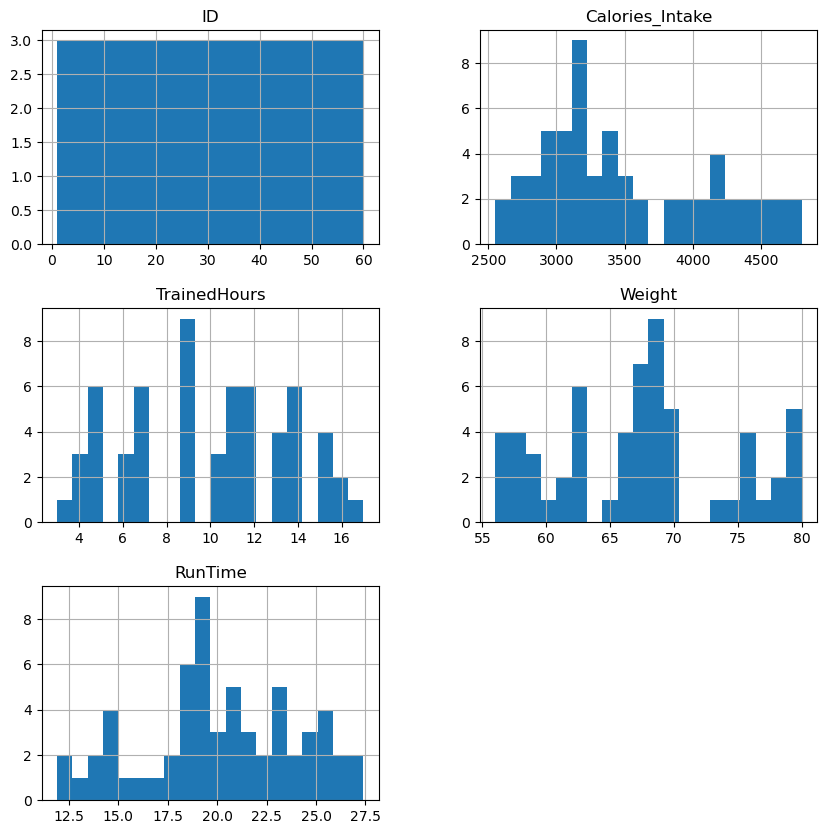

In [5]:
# Plot histograms
# Note: use small bins e.g., 20 bins to see the shapes better.
# Since some of the variables are discrete, you may see some blanks in your histograms. 

df.hist(figsize=(10,10), bins=20);

<Axes: >

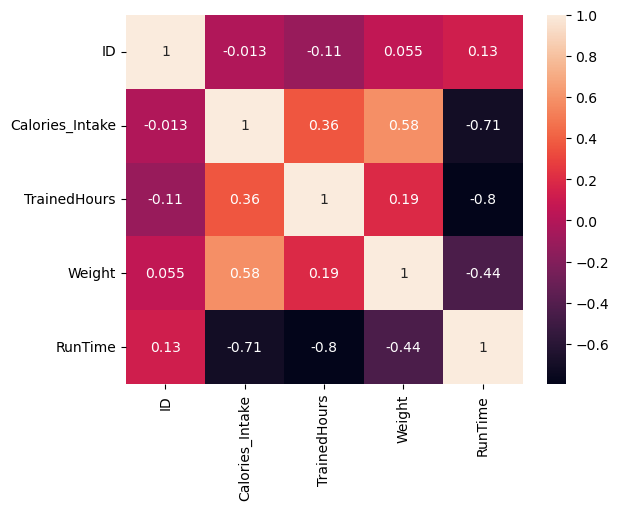

In [6]:
# Check correlations between all the variables using corr() and plot heatmap of the correlations using seaborn heatmap function.

sns.heatmap(df.corr(numeric_only = True), annot=True)

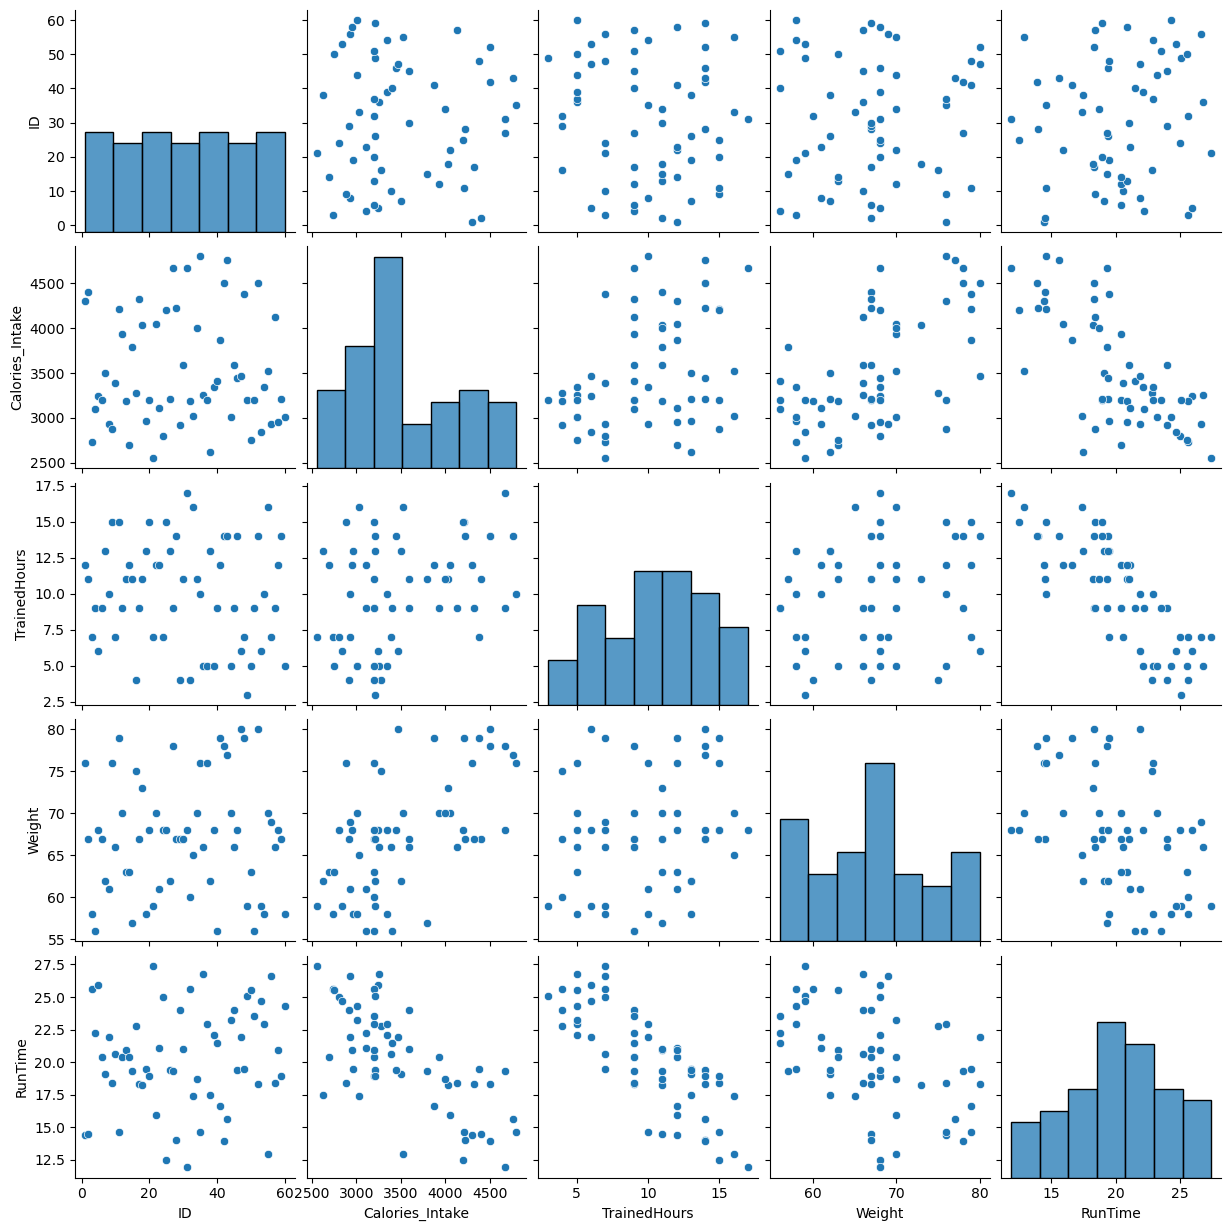

In [7]:
# Plot the scatter plots for pair-wise relationships comparisons

sns.pairplot(df)

### 2. Data Preparation

#### Encode Variables

Use the pd.get_dummies() functions to create dummy variables for Gender and Club. 
Remember you are must use the option drop_first = True when creating dummy variables for regression
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

In [8]:
# Use get_dummies function and store the variables in a new DataFrame
# Default datatype is bool, newer version of StatsModels requires the type to be numeric (e.g., int, float)
df2 = pd.get_dummies(df, columns = ['Gender','Club'], drop_first= True, dtype=int)
df2.head()

,ID,Calories_Intake,TrainedHours,Weight,RunTime,Gender_M,Club_B,Club_C
0,1,4300,12,76,14.4,1,0,0
1,2,4402,11,67,14.5,1,0,1
2,3,2736,7,58,25.6,0,0,0
3,4,3103,9,56,22.2,0,0,0
4,5,3244,6,68,25.9,0,1,0


#### Split Data into Train-Test sets

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Separate the X variables (use all numeric except 'ID' and encoded variables) and target variable (RunTime)

In [10]:
X = df2[['TrainedHours', 'Calories_Intake', 'Weight', 'Gender_M', 'Club_B','Club_C']]
y = df2['RunTime']

Use 75% of the data as Train data and 25% as Test data. 
Use random_state = 512

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.25,
                                                    random_state = 512)

### 3. Train Regression Model

Fit the linear regression model

In [12]:
lm = LinearRegression()
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Report the R-squared score of the model

In [13]:
# Call score() function
lm.score(X_train, y_train)

0.8713965087369331

Use statsmodel to show the statistics information of the linear regression model.
Remember to add a constant to the DataFrame.

In [14]:
import statsmodels.api as sm

In [15]:
# Remember to add constant to OLS model
X_train_const = sm.add_constant(X_train)
X_train_const.head()

,const,TrainedHours,Calories_Intake,Weight,Gender_M,Club_B,Club_C
25,1.0,13,3206,62,0,0,0
55,1.0,7,2927,69,0,0,0
47,1.0,7,4380,79,1,0,1
38,1.0,5,3345,68,0,0,0
42,1.0,14,4756,77,1,0,0


In [16]:
# Fit a model using OLS 
model = sm.OLS(y_train, X_train_const)
model_results = model.fit()

In [17]:
# Return the summary tables of the regression results
model_results.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.851   
Dependent Variable: RunTime          AIC:                171.2121
Date:               2026-02-11 11:48 BIC:                183.8587
No. Observations:   45               Log-Likelihood:     -78.606 
Df Model:           6                F-statistic:        42.91   
Df Residuals:       38               Prob (F-statistic): 1.93e-15
R-squared:          0.871            Scale:              2.2814  
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
const             34.0347   3.0476 11.1677 0.0000 27.8652 40.2043
TrainedHours      -0.5966   0.0724 -8.2461 0.0000 -0.7431 -0.4502
Calories_Intake   -0.0020   0.0006 -3.2457 0.0024 -0.0032 -0.0007
Weight             0.0019   0.0526  0.0368 0.9708 -0.1046  0.1085
Gender_M          -2.2744   0.7388 -3.0784 0.0039 -3.7701 -0.7787
Club_B            -0.3539   0.5717 -0.6191 0.5396 -1.5113  0.8034
Club_C            -0.1357   0.5995 -0.2264 0.8221 -1.3494  1.0779
-----------------------------------------------------------------
Omnibus:              3.511        Durbin-Watson:           2.150
Prob(Omnibus):        0.173        Jarque-Bera (JB):        1.662
Skew:                 0.049        Prob(JB):                0.436
Kurtosis:             2.064        Condition No.:           48061
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 4.81e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

### 4. Fine-tune the model


#### 4.1 Develop a model with only significant variables

Using a 5% significance level, drop the insignificant variables.

In practice, we typically remove the variable with the highest p-value first, refit the regression model, and then check whether any remaining variables are still insignificant.

For this exercise, to save time and keep the code simple, we will drop all insignificant variables in a single step.

In this case, the insignificant variables are the `Club` dummy variables and `Weight`.


In [18]:
# Obtain a DataFrame X2 containing the independent variables which are significant
X2 = df2[['TrainedHours', 'Calories_Intake', 'Gender_M']]
X2.head()

,TrainedHours,Calories_Intake,Gender_M
0,12,4300,1
1,11,4402,1
2,7,2736,0
3,9,3103,0
4,6,3244,0


In [19]:
# Get the Train-Test datasets again (you may use a different set of variable names to avoid confusion)
# Remember to use the same random_state as before
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y,
                                                    test_size = 0.25,
                                                    random_state = 512)


In [20]:
# Train a new linear regression model lm2 and report the R-squared
lm2 = LinearRegression()
lm2.fit(X_train2,y_train2)
lm2.score(X_train2, y_train2)

0.870093578992897

In [21]:
# Using the statsmodel OLS function
# Remember to add constant

X_train_const2 = sm.add_constant(X_train2)
X_train_const2.head()

,const,TrainedHours,Calories_Intake,Gender_M
25,1.0,13,3206,0
55,1.0,7,2927,0
47,1.0,7,4380,1
38,1.0,5,3345,0
42,1.0,14,4756,1


In [22]:
# Get the OLS model by fitting the model and printing out the summary statistics of the results
model2 = sm.OLS(y_train2, X_train_const2)
model_results2 = model2.fit()
model_results2.summary2()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.861   
Dependent Variable: RunTime          AIC:                165.6657
Date:               2026-02-11 11:48 BIC:                172.8923
No. Observations:   45               Log-Likelihood:     -78.833 
Df Model:           3                F-statistic:        91.54   
Df Residuals:       41               Prob (F-statistic): 3.29e-18
R-squared:          0.870            Scale:              2.1359  
-----------------------------------------------------------------
                   Coef.  Std.Err.    t    P>|t|   [0.025  0.975]
-----------------------------------------------------------------
const             34.0297   1.6492 20.6346 0.0000 30.6991 37.3602
TrainedHours      -0.6038   0.0648 -9.3218 0.0000 -0.7346 -0.4730
Calories_Intake   -0.0019   0.0005 -3.8431 0.0004 -0.0029 -0.0009
Gender_M          -2.3609   0.6548 -3.6054 0.0008 -3.6833 -1.0384
-----------------------------------------------------------------
Omnibus:              3.799        Durbin-Watson:           2.130
Prob(Omnibus):        0.150        Jarque-Bera (JB):        1.729
Skew:                 0.050        Prob(JB):                0.421
Kurtosis:             2.045        Condition No.:           27469
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
[2] The condition number is large, 2.75e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

<b>Results:</b>
- R-squared has decreased slightly compared to the first linear regression model. 
- Adjusted R-squared has increased.
- All the variables are significant at 5% significance level.


#### 4.2 Develop a model with standardized variables (using MinMaxScaler)

Notice that we have a binary variable in the data. Min–Max scaling leaves dummy variables unchanged, whereas it is best practice to exclude dummy variables when applying Z-score standardisation. For convenience, we will use Min–Max scaling in this exercise.


In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
# Going to use the same DataFrame X2 containing the independent variables which are significant
X2.head()

,TrainedHours,Calories_Intake,Gender_M
0,12,4300,1
1,11,4402,1
2,7,2736,0
3,9,3103,0
4,6,3244,0


In [25]:
# Instantiate a standard scale 
scaler = MinMaxScaler()

# Call fit_transform to standardize the variables in X2, save the output into variable X2_scaled
X2_scaled = scaler.fit_transform(X2)

In [26]:
# Put the output which is NumPy array into DataFrame called std_Df

std_df = pd.DataFrame(X2_scaled, columns = X2.columns)
std_df

,TrainedHours,Calories_Intake,Gender_M
0,0.642857,0.778718,1.0
1,0.571429,0.824132,1.0
2,0.285714,0.082369,0.0
3,0.428571,0.245770,0.0
4,0.214286,0.308549,0.0
5,0.428571,0.288958,1.0
6,0.714286,0.422529,0.0
7,0.500000,0.166963,0.0
8,0.857143,0.145147,1.0
9,0.285714,0.374889,1.0


In [27]:
# Get the Train-Test datasets again (you may use a different set of variable names to avoid confusion)
# Remember to use the same random_state as before
X_train3, X_test3, y_train3, y_test3 = train_test_split(std_df, y,
                                                    test_size = 0.25,
                                                    random_state = 512)

In [28]:
# Train a new linear regression model lm3 and report the R-squared
lm3 = LinearRegression()
lm3.fit(X_train3,y_train3)
lm3.score(X_train3, y_train3)

0.8700935789928971

In [29]:
# Using the statsmodel OLS function
# Remember to add constant

X_train_const3 = sm.add_constant(X_train3)
X_train_const3.head()

,const,TrainedHours,Calories_Intake,Gender_M
25,1.0,0.714286,0.291630,0.0
55,1.0,0.285714,0.167409,0.0
47,1.0,0.285714,0.814337,1.0
38,1.0,0.142857,0.353517,0.0
42,1.0,0.785714,0.981745,1.0


In [30]:
# Get the OLS model by fitting the model and printing out the summary statistics of the results
model3 = sm.OLS(y_train3, X_train_const3)
model_results3 = model3.fit()
model_results3.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.861   
Dependent Variable: RunTime          AIC:                165.6657
Date:               2026-02-11 11:48 BIC:                172.8923
No. Observations:   45               Log-Likelihood:     -78.833 
Df Model:           3                F-statistic:        91.54   
Df Residuals:       41               Prob (F-statistic): 3.29e-18
R-squared:          0.870            Scale:              2.1359  
-----------------------------------------------------------------
                  Coef.  Std.Err.    t    P>|t|   [0.025   0.975]
-----------------------------------------------------------------
const            27.2936   0.5214 52.3452 0.0000  26.2406 28.3466
TrainedHours     -8.4528   0.9068 -9.3218 0.0000 -10.2841 -6.6215
Calories_Intake  -4.3359   1.1283 -3.8431 0.0004  -6.6145 -2.0574
Gender_M         -2.3609   0.6548 -3.6054 0.0008  -3.6833 -1.0384
-----------------------------------------------------------------
Omnibus:              3.799        Durbin-Watson:           2.130
Prob(Omnibus):        0.150        Jarque-Bera (JB):        1.729
Skew:                 0.050        Prob(JB):                0.421
Kurtosis:             2.045        Condition No.:           7    
=================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

<b>Note:</b>
The model’s performance, such as $R^2$, remains unchanged before and after scaling. Scaling does not change $R^2$ because it does not affect the fit of the model, only the scale of the coefficients. However, the coefficients are now more comparable across variables.

When Min–Max scaling is used, each coefficient represents the expected change in the dependent variable $Y$ associated with a one-unit increase in the scaled independent variable (i.e., moving from its minimum to its maximum), on average, holding other variables constant.



### 5. Check Linear Regression Assumptions

From this section onward, whether we proceed with `lm2` (before scaling) or `lm3` (after scaling) does not affect the results; the choice depends on individual preference.

For illustration purposes, the code will continue using `lm2`, as it is slightly more intuitive for beginners since the variables remain in their original units.


In [31]:
# Get the predicted value of the Train Dataset (remember to choose only the significant variables)
# Supposedly we use the lm2 model after standardardization to check the LR assumptions

y_model_pred = lm2.predict(X_train2.iloc[:,0:3]) # Use X_train2 which is before standardization
y_model_pred

array([19.99139695, 24.15263608, 18.98671817, 24.55322094, 14.03444801,
       24.52136508, 21.66129991, 18.64790989, 24.87851096, 22.41420204,
       18.52757798, 25.70380985, 20.05718825, 22.34325434, 18.75601429,
       25.19801405, 17.05812113, 25.29212798, 18.79736907, 20.7843585 ,
       17.21932635, 20.46244342, 24.7385507 , 25.97746197, 21.58359307,
       14.52286914, 25.45043048, 21.54401976, 16.12230586, 19.42382458,
       24.92822296, 16.52916375, 24.14443254, 17.24731656, 14.50404543,
       20.45182788, 18.93781544, 14.48860128, 25.19994457, 16.94856769,
       26.03296553, 20.89213972, 16.37037978, 17.3148847 , 22.60532335])

In [32]:
# Compute residuals
results = pd.DataFrame({'Actual': y_train, 'Predicted': y_model_pred})
results['residuals'] = results['Actual'] - results['Predicted']
results.head()

,Actual,Predicted,residuals
25,19.4,19.991397,-0.591397
55,26.6,24.152636,2.447364
47,19.5,18.986718,0.513282
38,22.1,24.553221,-2.453221
42,15.6,14.034448,1.565552


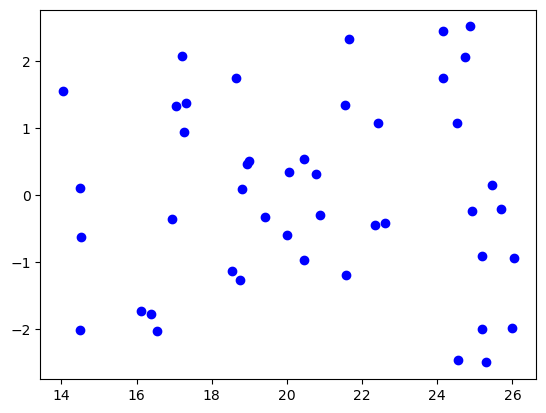

In [33]:
# Plot scatter plot of the residuals
plt.scatter(results['Predicted'], results['residuals'],  color='blue')

As the data is pretty small for this exercise, it is not too clear on histogram whether error is normally distributed. 

(array([2., 3., 2., 1., 1., 2., 3., 2., 5., 2., 3., 4., 1., 1., 2., 3., 3.,
        0., 2., 3.]),
 array([-2.49212798, -2.24144713, -1.99076628, -1.74008543, -1.48940457,
        -1.23872372, -0.98804287, -0.73736202, -0.48668117, -0.23600032,
         0.01468053,  0.26536138,  0.51604223,  0.76672308,  1.01740393,
         1.26808479,  1.51876564,  1.76944649,  2.02012734,  2.27080819,
         2.52148904]),
 <BarContainer object of 20 artists>)

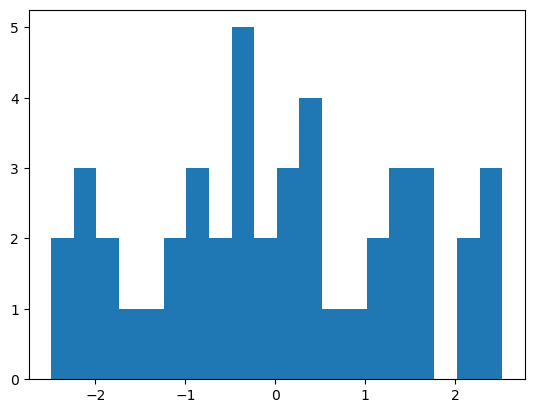

In [34]:
# Plot histogram of the errors (residuals)
plt.hist(results['residuals'], bins=20)

In [35]:
# Use a statistical test such as the K–S test to assess normality.
# The null hypothesis states that the data are normally distributed.
# The alternative hypothesis states that the data are not normally distributed.

from scipy import stats
from scipy.stats import norm, kstest

np.random.seed(500)

# getting the loc (mean) and scale (std dev) for residuals
loc, scale = norm.fit(results['residuals'])

# create a normal distribution with loc and scale
n = norm(loc=loc, scale=scale)

# perform the KS-test using residuals compared to a normal distribution in the correct scale
stat, p = stats.kstest(results['residuals'], n.cdf)

# print p-value: if p-value is <0.05 (5% significance), then reject null hypothesis 
print('Residuals: Statistics=%.3f, p=%.9f' % (stat, p))

Residuals: Statistics=0.076, p=0.937330828


The normality of the regression errors suggests that the standard inferential procedures (t-tests and F-tests) used in the regression analysis are appropriate.

### 6. Check Multicollinearity

Use VIF to test multicollinearity

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [37]:
# VIF computation (remember need to include the constant variable) for the regression model (with intercept).

for i in range(0,4):
    v = vif(X_train_const2.values, i)
    print("VIF for {}:{}".format(X_train_const2.columns[i], round(v, 4)))

VIF for const:57.2995
VIF for TrainedHours:1.1757
VIF for Calories_Intake:2.0066
VIF for Gender_M:2.1235


### 7. Evaluate the Model using Test dataset

In [38]:
from sklearn.metrics import r2_score 

# Predict and report the r-squared using Test dataset
y_pred = lm2.predict(X_test2)
r_squared_test = r2_score(y_test2, y_pred)

round(r_squared_test,4)

0.8229

In [39]:
# Compute the RMSE
from sklearn.metrics import mean_squared_error 
rmse = np.sqrt(mean_squared_error(y_test2, y_pred))
rmse

np.float64(1.51998066073462)